# Prosjekt 2: Analyse av politisk innflytelse

Prosjektet inneholder de følgende analysene:

1. Overfladisk statistisk analyse av datasettet. Hvor ofte samsvarer gruppenes mening med det som blir gjennomført? Hva med når de er uenige (hvem vinner)?
2. Koeffisienter for logistisk regresjon med kun en gruppe som treningsgrunnlag
3. Koeffisienter for logistisk regresjon når treningsgrunnlaget er uenighet mellom to grupper (rich minus poor)
4. Undersøkelse av feature importance vha. random forest modeller


# 0. Importering og behandling av datasett

In [384]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [385]:
df_DS1 = pd.read_stata("DS1_v2.dta")

In [386]:
all_cols = ['pred10_sw', 'pred30_sw', 'pred50_sw', 'pred70_sw', 'pred90_sw', 'PREDALL_SW']

In [387]:
clean_df = df_DS1.dropna(subset=['OUTCOME'] + all_cols, how='any')

In [388]:
df_DS1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Columns: 265 entries, ID8102 to _merge
dtypes: category(1), float64(262), str(2)
memory usage: 3.8 MB


In [389]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 1836 entries, 0 to 1862
Columns: 265 entries, ID8102 to _merge
dtypes: category(1), float64(262), str(2)
memory usage: 3.7 MB


In [390]:
print(clean_df.groupby('XL_AREA').size())

XL_AREA
budget           23
camp finance     64
civil rts        46
defense          63
econ & labor    110
education        63
environment      62
foreign pol     302
govt reform      39
guns             99
health          157
immigration      23
misc others     110
race             20
religious        94
soc welfare     136
taxation        284
terrorism        78
welf reform      63
dtype: int64


# 1. Overordnet analyse av datasett

In [391]:
lower_tresholds_fine  = np.linspace(0,0.9,10)
lower_tresholds_coarse = np.array([0, 0.3, 0.7])

In [392]:
def return_agreement_scores(df, category, group, lower_tresholds):
    if category != 'ALLCATS':
        sorted_cat = df[df['XL_AREA'] == category]
    else:
        sorted_cat = df
    
    agreement_scores = np.zeros_like(lower_tresholds, dtype=float)
    
    for i, treshold in enumerate(lower_tresholds):
        next_treshold = lower_tresholds[i+1] if i+1 < len(lower_tresholds) else 1.0
        df_in_treshold = sorted_cat[(sorted_cat[group] >= treshold) & (sorted_cat[group] <= next_treshold)]
        
        if len(df_in_treshold) > 0:
            score = (df_in_treshold['OUTCOME'] != 0).mean()
        else:
            score = np.nan  # Handle bins with no data points
            print(f"No data points for {group} in treshold range [{treshold}, {next_treshold}]")

        agreement_scores[i] = score

    return agreement_scores
    

In [393]:

def influence_graph(agreement_scores_list, category, groups, lower_tresholds):
    n_groups = len(groups)
    n_bins = len(lower_tresholds)

    x = np.arange(n_bins)
    bar_width = 0.8 / n_groups if n_groups > 0 else 0.8

    plt.figure(figsize=(12, 6))

    for i, (scores, group_name) in enumerate(zip(agreement_scores_list, groups)):
        plt.bar(x + i * bar_width, scores, width=bar_width, label=group_name)

    # Midpoint labels for each threshold interval
    bin_labels = [
        f"[{lower_tresholds[i]:.1f}, {lower_tresholds[i+1]:.1f}]"
        if i + 1 < n_bins else f"[{lower_tresholds[i]:.1f}, 1.0]"
        for i in range(n_bins)
    ]

    plt.xticks(x + (n_groups - 1) * bar_width / 2, bin_labels, rotation=45, ha='right')
    plt.ylim(0, 1)
    plt.xlabel("Agreement interval")
    plt.ylabel("Andel vedtatt (agreement score)")
    plt.title(f"Agreement score per group ({category})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [394]:
def create_influence_graph(df, category, groups, lower_tresholds):
    agreement_scores_list = [return_agreement_scores(df, category, group, lower_tresholds) for group in groups]
    influence_graph(agreement_scores_list, category, groups, lower_tresholds)

### Alle saker

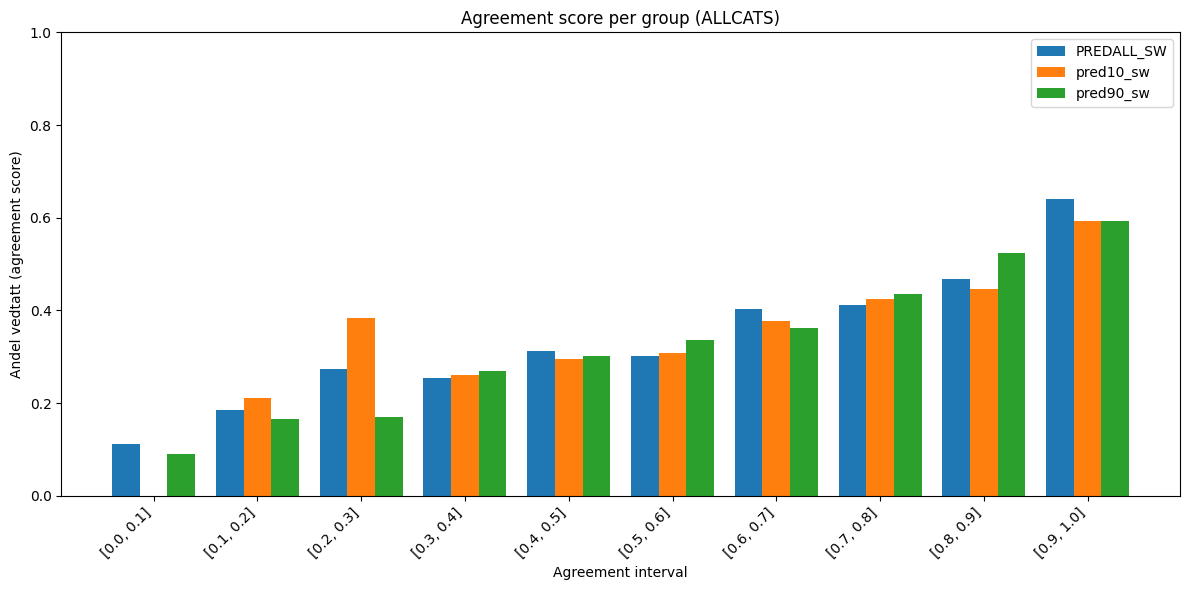

In [395]:
groups_extreme = ['PREDALL_SW', 'pred10_sw', 'pred90_sw']
lower_tresholds = [0.0, 0.25, 0.5, 0.75, 1.0]
create_influence_graph(clean_df, 'ALLCATS', groups_extreme, lower_tresholds_fine)


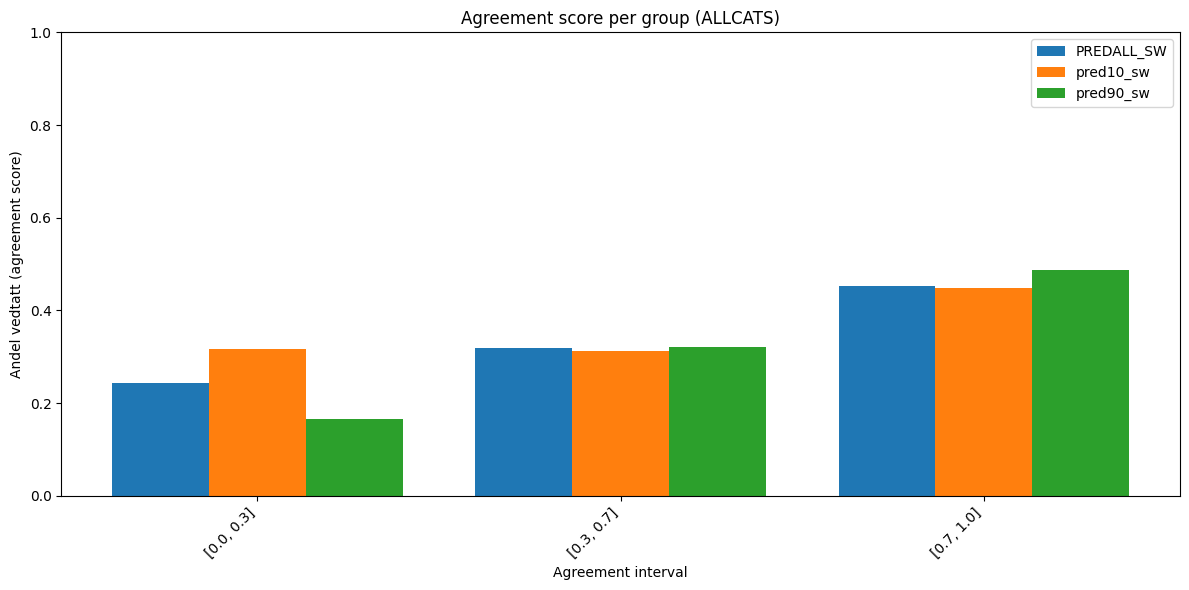

In [396]:
create_influence_graph(clean_df, 'ALLCATS', groups_extreme, lower_tresholds_coarse)

### Kun de sakene der det er uenighet mellom rike og fattige

In [397]:
conflict_df = clean_df[abs(clean_df['pred90_sw'] - clean_df['pred10_sw']) >= 0.15]
conflict_df.info()

<class 'pandas.DataFrame'>
Index: 378 entries, 0 to 1862
Columns: 265 entries, ID8102 to _merge
dtypes: category(1), float64(262), str(2)
memory usage: 783.0 KB


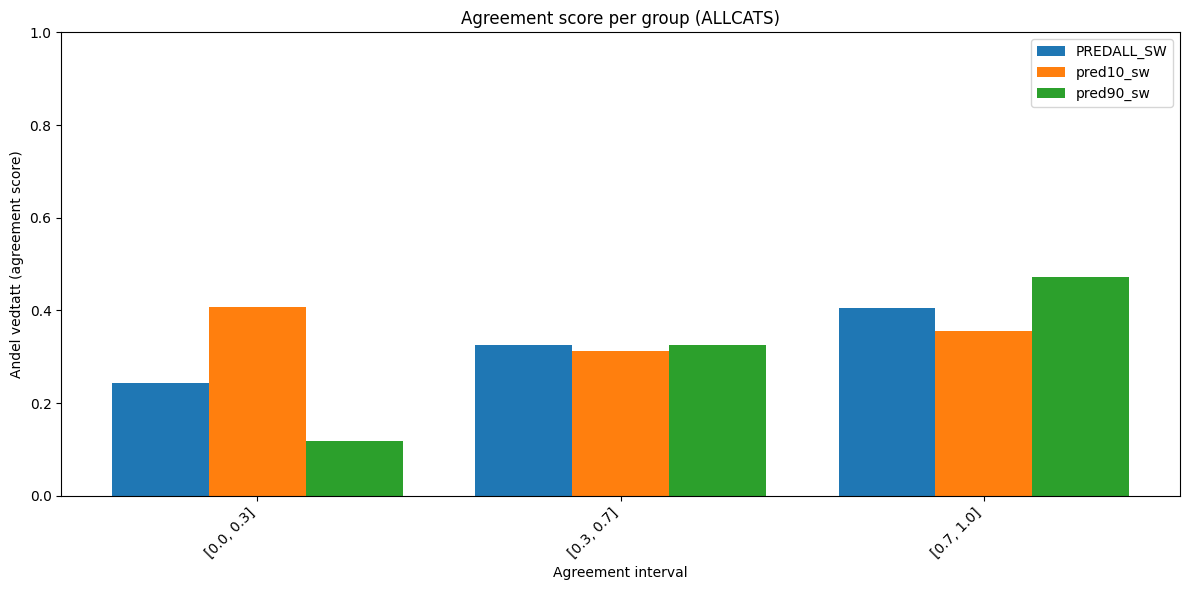

In [398]:
create_influence_graph(conflict_df, 'ALLCATS', groups_extreme, lower_tresholds_coarse)

# 2. Logistisk regresjon

In [399]:
def return_logistic_coefficients(df, groups):
    coeffs_by_group = {group: {} for group in groups}
    categories = sorted(df['XL_AREA'].unique())

    for category_name in categories:
        cat_df = df[df['XL_AREA'] == category_name]

        for group in groups:
            model_df = cat_df[[group, 'OUTCOME']]

            if model_df.empty:
                coeffs_by_group[group][category_name] = np.nan
                continue

            y = (model_df['OUTCOME'] != 0).astype(int)
            if y.nunique() < 2:
                coeffs_by_group[group][category_name] = np.nan
                continue

            X = model_df[[group]]
            model = LogisticRegression(max_iter=1000, C=np.inf)
            model.fit(X, y)

            coeffs_by_group[group][category_name] = float(model.coef_[0][0])

    return coeffs_by_group

In [400]:
def plot_logistic_coefficients(coef_df, groups):
    plt.figure(figsize=(12, 6))
    sns.heatmap(coef_df[groups], annot=True, cmap='coolwarm', center=0)
    plt.title("Logistic Regression Coefficients by Group")
    plt.xlabel("Features")
    plt.ylabel("Groups")
    plt.tight_layout()
    plt.show()

In [401]:
groups_all = ['pred10_sw', 'pred30_sw', 'pred50_sw', 'pred70_sw', 'pred90_sw', 'PREDALL_SW']

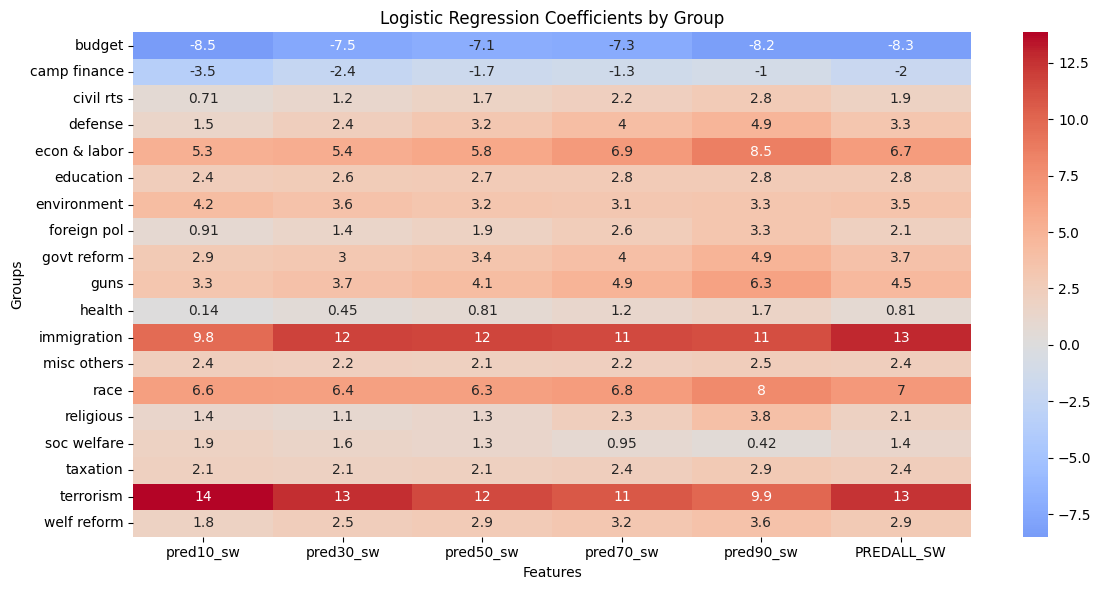

In [402]:
coefs_by_group = return_logistic_coefficients(clean_df, groups_all)
plot_logistic_coefficients(pd.DataFrame(coefs_by_group), groups_all)